# Commande PID de la balle sur poutre


Ce notebook synthétise et simule un correcteur **PID discret** pour le modèle de **balle sur poutre**.

Le système est un **double intégrateur** : $F(s) = H/s^2$ avec $H \approx 0{,}21\ \text{m\,s}^{-2}/\text{rad}$. Le système est non-asymptotiquement stable, il a besoin d'un correcteur en boucle fermée pour commander la position de la balle.
Deux simulations sont comparées : le modèle discret linéaire (fonctions de transfert) et la dynamique non linéaire continue intégrée numériquement.

Premièrement, il est conseillé d'exécuter les cellules une par une, de regarder les résultats et de lire les questions sans chercher à y répondre immédiatement. Une fois le notebook pris en main, revenir sur les paramètres à modifier et regarder les résultats.

In [2]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel
from Models.BallBeam.NonlinearDynamics import NonlinearBallBeamModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim
from Simulation.simulation import NonLinearHybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting
from Metrics_Plotting.Metrics import Metrics

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

### Configuration de la simulation :

T est le temps total de simulation et dt est la période d'échantillonnage du correcteur, la perturbation survient à 3 secondes.

In [3]:
ballbeam_config.T=6
ballbeam_config.dt=0.05

In [4]:
X_0 = np.array([[0.0],[0]])                                  # État initial [position [m], vitesse [m/s]]
bb_TF = TransferFunctionModel(ballbeam_config)       # Modèle en fonctions de transfert
modele_NL = NonlinearBallBeamModel(ballbeam_config)          # Modèle non linéaire
sim_NL = NonLinearHybridSim(modele_NL, ballbeam_config)      # Simulateur non linéaire (RK4)
bb_sim_dis = TFSimulator(bb_TF.Tf_dis, X_0)  # Simulateur discret (FT)
A = bb_TF.Tf_dis.den_list[0][0]                      # Dénominateur A(z) de la FT discrète
B = bb_TF.Tf_dis.num_list[0][0]                      # Numérateur B(z) de la FT discrète

In [5]:
## Affichage de la fonction de transfert continue et discrète
print(bb_TF.Tf_cont)
print(bb_TF.Tf_dis)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z + 0.0002625
  -----------------------
       z^2 - 2 z + 1


##### Questions :
- Quel est l'ordre de la fonction de transfert discrète affichée ? Combien de pôles possède-t-elle ?
- Les pôles en boucle ouverte sont-ils à l'intérieur du cercle unité ($|z| < 1$) ? Le système est-il stable sans correcteur ?

### Choix des gains PID

> **Pourquoi $K_i = 0$ ?**  
> L'erreur statique sur un échelon de consigne, dans le cas d'un double intégrateur, est nulle sans action intégrale. Ajouter $K_i \neq 0$ crée une boucle avec trois pôles à $z = 1$ en boucle ouverte, ce qui rend la boucle fermée plus difficile à stabiliser.  
>Pour l'instant ne changez pas les gains, regardez la réponse avec ceux proposés ci-dessous
> À la fin du document, il est proposé d'ajuster les gains du PID afin d'améliorer la réponse 

In [6]:
kp = 43
ki = 0 # ne pas modifier pour la première exécution
kd = 21

##### Questions :
- Quel effet a une augmentation de $K_p$ sur la rapidité de la réponse ? Et sur la stabilité ?
- Quel rôle joue $K_d$ dans la réponse transitoire ?
- D'après l'explication ci-dessus, pourquoi choisit-on $K_i = 0$ ici ?

### Synthèse du correcteur PID

On instancie le correcteur PID discret avec les gains choisis. Le mot-clé `"filtered"` active un filtre passe-bas sur l'action dérivée afin d'éviter l'amplification du bruit haute fréquence.

In [7]:
PID_controller=DiscretePID(kp,ki,kd,ballbeam_config.dt,"filtered")

### Analyse en boucle fermée

On calcule la transmittance en boucle ouverte $L(z) = C_{PID}(z) \cdot P(z)$, puis la transmittance en boucle fermée :

$$H_{bf}(z) = \frac{L(z)}{1 + L(z)}$$

Pour que le système soit stable, tous les pôles de $H_{bf}(z)$ (racines du dénominateur) doivent être situés à l'intérieur du cercle unité ($|z| < 1$). Le DC gain de $H_{bf}$ doit être égal à 1 pour un suivi parfait d'un échelon de consigne.

In [8]:
L = PID_controller.transferFunction * bb_TF.Tf_dis
H_bf = ct.feedback(L, 1)
print(H_bf)
print("DC gain:       ", H_bf.dcgain())
cl_poles = np.roots(H_bf.den_list[0][0])
print("Closed-loop poles (z):", cl_poles)
print("Pole radii:           ", np.abs(cl_poles))

<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

     0.3151 z^2 + 0.02822 z - 0.2869
  -------------------------------------
  3.5 z^3 - 7.685 z^2 + 5.528 z - 1.287
DC gain:        0.9999999999999921
Closed-loop poles (z): [0.84029928+0.08802537j 0.84029928-0.08802537j 0.51507823+0.j        ]
Pole radii:            [0.84489724 0.84489724 0.51507823]


##### Questions :
- Tous les rayons des pôles en boucle fermée (`Pole radii`) sont-ils inférieurs à 1 ? Le système est-il stable ?
- Le gain statique de $H_{bf}$ est-il proche de 1 ? Qu'est-ce que cela implique pour le suivi d'une consigne en échelon ?
- Un pôle réel proche de 0 est-il plus ou moins rapide qu'un pôle réel proche de 1 ?

### Marges de stabilité

Les marges de gain et de phase quantifient la robustesse de la boucle fermée. Les cibles habituelles sont $\text{MG} > 6\ \text{dB}$ et $\text{MP} > 45°$.



In [9]:
metriques = Metrics()
metriques.Stability(L)

Gain margin:   17.6 dB  (×7.57)
Phase margin:  49.6°


##### Questions :
- La marge de gain affichée est-elle supérieure à la cible de 6 dB ?
- La marge de phase est-elle supérieure à la cible de 45° ?
- Que se passerait-il si l'on augmentait fortement $K_p$ ? (La marge de gain diminuerait-elle ?)

### Simulation
On utilise le simulateur discret. Le premier True/False détermine la présence d'une **perturbation d'entrée en échelon** ($D = 2$, constante à partir de $t = 3$ s) injectée à l'entrée du procédé — le système reçoit $u + d$ tandis que $u$ est la sortie brute du correcteur. Le deuxième active (si True) la saturation de l'actionneur fixé à $\pm 10 [rad]$.

In [10]:
logger_PID = SimLog()

reference = 1.0
y_0 = 0.0

logger_PID = run_discrete_control(bb_sim_dis, PID_controller, ballbeam_config, reference, y_0, logger_PID, True, True)

### Métriques de performance

Dépassement, temps de montée (10 %=>90 %) et temps d'établissement (bande ±10 %) calculés sur la phase de suivi de consigne (avant $t=3s$).

Le dépassement observé peut être supérieur à la cible théorique en raison de la saturation de l'actionneur en début de réponse : le signal $u(t)$ est borné entre ±10 rad.

In [11]:
metriques.response_data(logger_PID, reference)

Dépassement :          0.5 %
Temps de montée :      0.850 s  (10 %=>90 %)
Temps d'établissement :     1.150 s  (bande ±10 %)


### Rejet de perturbation d'entrée en échelon

La fonction de transfert **perturbation d'entrée => position** est :

$$F_p(z) = \frac{B(z)\,S_{PID}(z)}{A(z)\,S_{PID}(z) + B(z)\,R_{PID}(z)}$$

La perturbation est un **échelon constant** $D = 2$ injecté à l'entrée de la plante à partir de $t = 3$ s.

**Erreur statique** ($z = 1$, avec $A(1) = 0$) :

$$F_p(1) = \frac{S_{PID}(1)}{R_{PID}(1)} $$

> **Pourquoi $K_i = 0$ laisse une erreur statique ?** Sans action intégrale, le correcteur ne peut pas intégrer l'erreur de position. À l'état stationnaire, l'erreur $e_\infty = y - r$.

Comparer avec le RST (notebook suivant) - activez l'effet intégral sur $S(z)$ 

In [12]:
A_arr = np.squeeze(A)
B_arr = np.squeeze(B)
R_arr = np.squeeze(PID_controller.R.num[0][0])
S_arr = np.squeeze(PID_controller.S.num[0][0])

# Perturbation d'entrée => position : Fp_in = B·S / (A·S + B·R)
num_p = np.polymul(B_arr, S_arr)
den_p = np.polyadd(np.polymul(A_arr, S_arr), np.polymul(B_arr, R_arr))

Fp = ct.tf(num_p, den_p, ballbeam_config.dt)
print(Fp)
print(f"Gain statique Fp(z=1) : {Fp.dcgain():.6f}")

t = np.arange(0, ballbeam_config.T, ballbeam_config.dt)
t = np.asarray(t).flatten()
_, d_resp = ct.step_response(Fp, t)
d_resp = np.squeeze(d_resp)

<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0009187 z^2 + 0.0006563 z - 0.0002625
  ---------------------------------------
   3.5 z^3 - 7.685 z^2 + 5.528 z - 1.287
Gain statique Fp(z=1) : 0.023256


### Affichage des résultats

Trois courbes sont tracées : la position réelle $y_{plant}(t)$, la commande $u(t)$ (sans $d$), et la réponse indicielle de $D \cdot F_p(z)$.

Après $t = 3$ s, la perturbation d'entrée $D = 2$ agit en permanence.

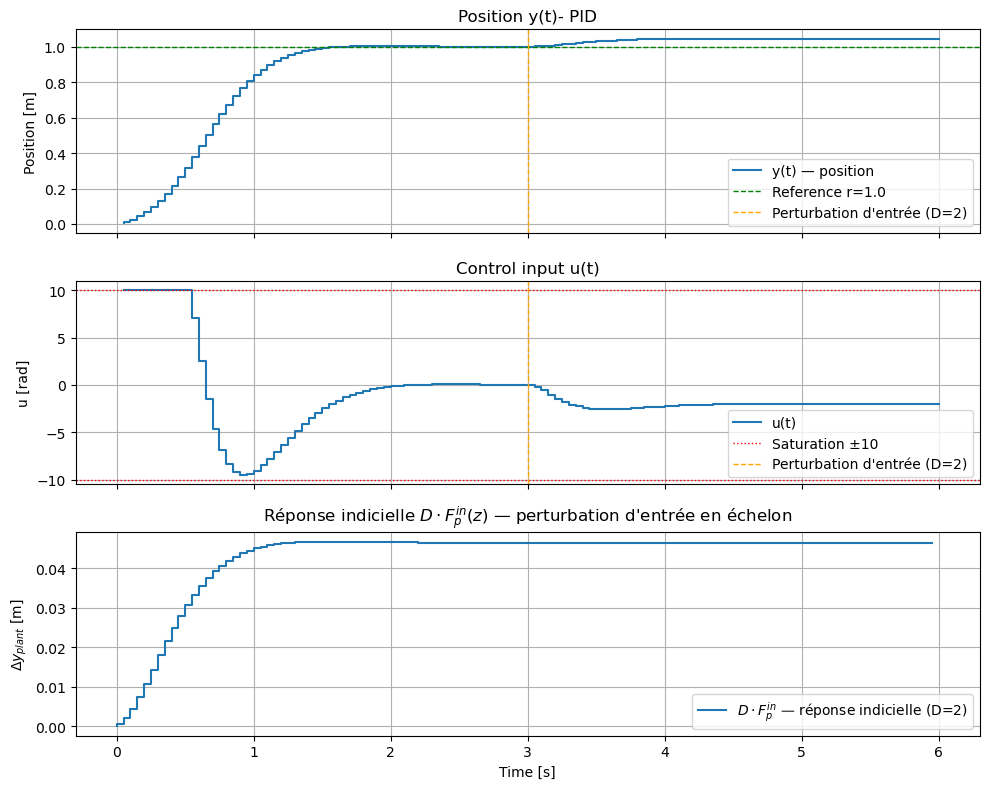

In [13]:
D = 2.0  # magnitude de la perturbation d'entrée

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].step(logger_PID.t_hist, logger_PID.y_hist, label='y(t) — position ')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Reference r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label="Perturbation d'entrée (D=2)")
ax[0].set_title("Position y(t)- PID")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].step(logger_PID.t_hist, logger_PID.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label="Perturbation d'entrée (D=2)")
ax[1].set_title("Control input u(t)")
ax[1].set_ylabel("u [rad]")
ax[1].legend()
ax[1].grid()

ax[2].step(t, D * d_resp, label=f"$D \\cdot F_p^{{in}}$ — réponse indicielle (D=2)")
ax[2].set_title("Réponse indicielle $D \\cdot F_p^{in}(z)$ — perturbation d'entrée en échelon")
ax[2].set_ylabel("$\\Delta y_{plant}$ [m]")
ax[2].set_xlabel("Time [s]")
ax[2].legend()
ax[2].grid()

plt.tight_layout()
### pour enregistrer la figure décommenter ceci
#plt.savefig("Commande_PID_figure1")
plt.show()

##### Questions :
- La position réelle $y_{plant}(t)$ atteint-elle la consigne $r = 1{,}0$ m avant $t = 3$ s ? Y a-t-il un dépassement ?
- Après la perturbation d'entrée $D = 2$ à $t = 3$ s, la position revient-elle exactement à $r$ ? Mesurer l'erreur statique et comparer avec $D / K_p$.
- Le signal de commande $u(t)$ sature-t-il après la perturbation ? Quelle est la valeur de $u_{t\rightarrow \infty}$ à l'état stationnaire ?

## Simulation non linéaire

Le simulateur linéaire ci-dessus utilise la fonction de transfert discrète exacte du procédé. Ici on remplace le procédé par la **dynamique non linéaire** de la balle sur poutre, intégrée par RK4 à $dt_\text{syst} = 1\ \text{ms}$, le correcteur étant mis à jour toutes les $dt = 50\ \text{ms}$ (maintien d'ordre zéro).

Différences attendues par rapport à la simulation linéaire :
- La saturation de $u$ peut retarder la compensation initiale de la perturbation d'entrée.
- Les non-linéarités de $\sin\alpha$ peuvent modifier légèrement l'erreur statique observée

In [14]:
logger_NL = SimLog()
logger_NL = run_continuous_control_loop(sim_NL, PID_controller, reference, X_0, logger_NL, True, True)

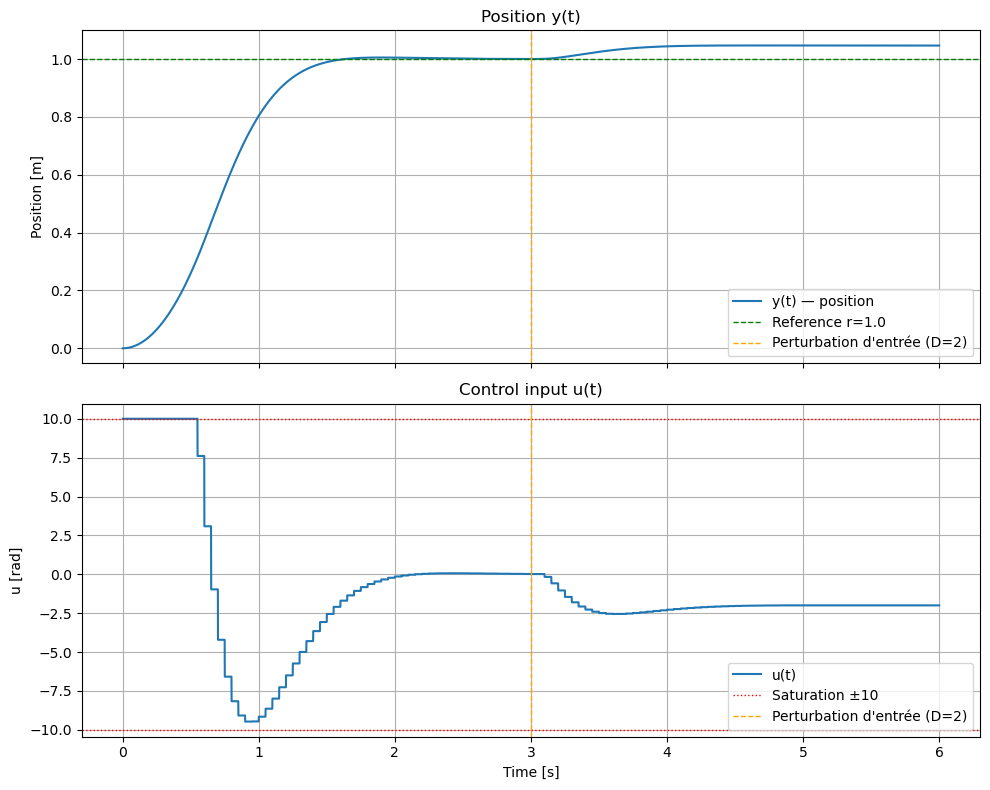

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(logger_NL.t_hist, logger_NL.y_hist, label='y(t) — position')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Reference r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label="Perturbation d'entrée (D=2)")
ax[0].set_title("Position y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].plot(logger_NL.t_hist, logger_NL.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label="Perturbation d'entrée (D=2)")
ax[1].set_title("Control input u(t)")
ax[1].set_ylabel("u [rad]")
ax[1].set_xlabel("Time [s]")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
### pour enregistrer la figure décommenter ceci
#plt.savefig("Commande_PID_figure2")
plt.show()

##### Questions :
- L'erreur statique après la perturbation d'entrée est-elle la même dans la simulation linéaire et non linéaire ?
- La commande $u(t)$ diffère-t-elle significativement entre les deux simulations à l'état stationnaire ?
- Quelle serait l'erreur statique si l'on augmentait $K_p$ ? Si l'on mettait $K_i \neq 0$ (attention à la stabilité) ?

#### Changer les gains du PID

Testez plusieurs combinaisons de gains $K_p$, $K_i$, $K_d$ et observez leur influence sur la réponse de la sortie et le rejet de perturbations.

**Rappel :** remontez jusqu'à la cellule qui contient `kp`, `ki` et `kd`, modifiez leurs valeurs, puis exécutez cette cellule et toutes les cellules suivantes.

Quelle est selon vous la meilleure combinaison ? Expliquez pourquoi (il n'y a pas de bonne réponse, c'est la justifiaction qui compte le plus).

#### Changer $dt$

Testez plusieurs valeurs de dt et observez leur influence sur la réponse de la sortie et le rejet de perturbations.

**Rappel :** remontez jusqu'à la cellule qui contient `dt`, modifiez leurs valeurs, puis exécutez cette cellule et toutes les cellules suivantes.

Que se passe-t-il ? Expliquez pourquoi.